In [ ]:
%%writefile MANDELBROT_CUDA.cu
#include <iostream>
#include <cuda.h>
#include <chrono>
#include <fstream>

using namespace std;

// ---------------- GPU KERNEL ----------------
__global__ void mandelbrotKernel(int *image, int width, int height, int max_iter) {
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;

    if (x < width && y < height) {

        float zx = 0.0f, zy = 0.0f;
        float cx = (x - width / 2.0f) * 4.0f / width;
        float cy = (y - height / 2.0f) * 4.0f / height;

        int count = 0;

        while (zx * zx + zy * zy < 4.0f && count < max_iter) {
            float temp = zx * zx - zy * zy + cx;
            zy = 2.0f * zx * zy + cy;
            zx = temp;
            count++;
        }

        image[y * width + x] = count;
    }
}

// ---------------- CPU VERSION ----------------
void mandelbrotCPU(int *image, int width, int height, int max_iter) {
    for (int x = 0; x < width; x++) {
        for (int y = 0; y < height; y++) {

            float zx = 0.0f, zy = 0.0f;
            float cx = (x - width / 2.0f) * 4.0f / width;
            float cy = (y - height / 2.0f) * 4.0f / height;

            int count = 0;

            while (zx * zx + zy * zy < 4.0f && count < max_iter) {
                float temp = zx * zx - zy * zy + cx;
                zy = 2.0f * zx * zy + cy;
                zx = temp;
                count++;
            }

            image[y * width + x] = count;
        }
    }
}

// ---------------- MAIN ----------------
int main() {

    ofstream file("result.txt");
    file << "SIZE,CPU_TIME,GPU_TIME,SPEEDUP,EFFICIENCY\n";

    int sizes[] = {256, 512, 1024, 2048, 3072};
    int max_iter = 100;

    for (int size : sizes) {

        int width = size;
        int height = size;
        int total = width * height;

        int *h_image = new int[total];
        int *d_image;

        cudaMalloc(&d_image, total * sizeof(int));

        // -------- CPU --------
        auto start = chrono::high_resolution_clock::now();
        mandelbrotCPU(h_image, width, height, max_iter);
        auto end = chrono::high_resolution_clock::now();
        double cpu_time = chrono::duration<double, milli>(end - start).count();

        // -------- GPU --------
        dim3 threads(16, 16);
        dim3 blocks((width + 15)/16, (height + 15)/16);

        start = chrono::high_resolution_clock::now();
        mandelbrotKernel<<<blocks, threads>>>(d_image, width, height, max_iter);
        cudaDeviceSynchronize();
        end = chrono::high_resolution_clock::now();
        double gpu_time = chrono::duration<double, milli>(end - start).count();

        double speedup = cpu_time / gpu_time;
        int cores = 2560; // T4 GPU
        double efficiency = speedup / cores;

        cout << "Size=" << size
             << " CPU=" << cpu_time
             << " GPU=" << gpu_time
             << " Speedup=" << speedup << endl;

        file << size << ","
             << cpu_time << ","
             << gpu_time << ","
             << speedup << ","
             << efficiency << "\n";

        cudaFree(d_image);
        delete[] h_image;
    }

    file.close();
    cout << "\nSaved results to result.txt\n";

    return 0;
}

Writing MANDELBROT_CUDA.cu


In [ ]:
!nvcc  MANDELBROT_CUDA.cu -o mandel

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [ ]:
!./mandel

Size=256 CPU=6.54088 GPU=101.204 Speedup=0.0646306
Size=512 CPU=25.7963 GPU=0.059079 Speedup=436.641
Size=1024 CPU=105.681 GPU=0.107822 Speedup=980.145
Size=2048 CPU=428.892 GPU=0.300615 Speedup=1426.72
Size=3072 CPU=995.179 GPU=0.56986 Speedup=1746.36

Saved results to result.txt


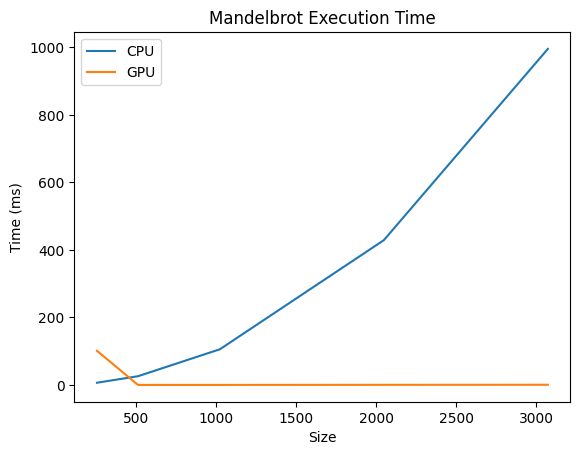

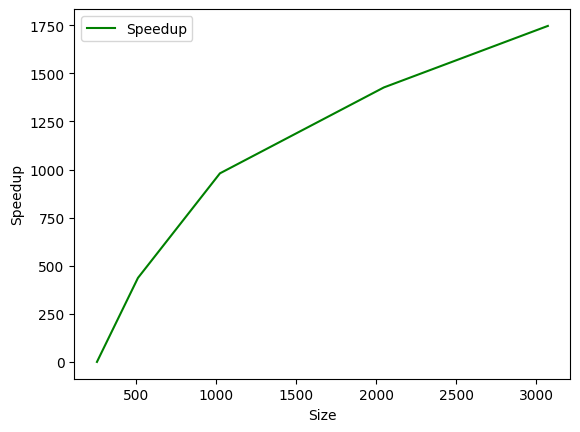

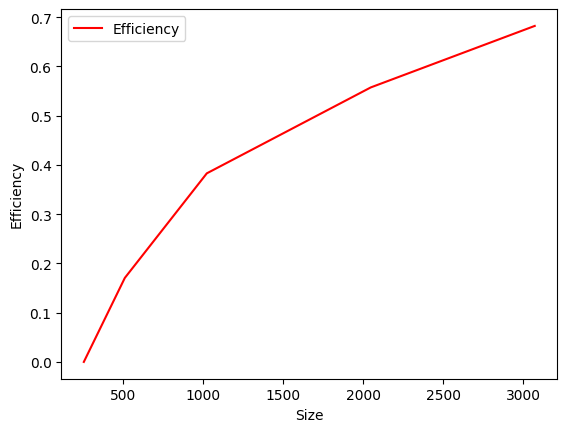

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("result.txt")

# 1. Time
plt.plot(df.SIZE, df.CPU_TIME, label="CPU")
plt.plot(df.SIZE, df.GPU_TIME, label="GPU")
plt.xlabel("Size")
plt.ylabel("Time (ms)")
plt.title("Mandelbrot Execution Time")
plt.legend()
plt.show()

# 2. Speedup
plt.plot(df.SIZE, df.SPEEDUP, label="Speedup", color='green')
plt.xlabel("Size")
plt.ylabel("Speedup")
plt.legend()
plt.show()

# 3. Efficiency
plt.plot(df.SIZE, df.EFFICIENCY, label="Efficiency", color='red')
plt.xlabel("Size")
plt.ylabel("Efficiency")
plt.legend()
plt.show()